[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/StormMaze/Lung-Cancer-Detection-Model/blob/main/LungCancerDetection.ipynb)

In [67]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt

In [68]:
#laod data
data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Data/lung_cancer.csv")

In [69]:
#feature and target selection
X = data.drop(columns='LUNG_CANCER')
y = data['LUNG_CANCER']

In [70]:
#categorical and numerical feature

categorical_features = ['GENDER']
binary_categorical_features = [
    'SMOKING', 'YELLOW_FINGERS', 'ANXIETY', 'PEER_PRESSURE', 'CHRONIC DISEASE',
    'FATIGUE', 'ALLERGY', 'WHEEZING', 'ALCOHOL CONSUMING', 'COUGHING',
    'SHORTNESS OF BREATH', 'SWALLOWING DIFFICULTY', 'CHEST PAIN'
]
numerical_features = ['AGE']

In [71]:
#ColumnTransformer for data preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(), categorical_features),  # OneHotEncode categorical features
        ('num', StandardScaler(), numerical_features),   # Standardize numerical features
        ('bin', 'passthrough', binary_categorical_features)  # Keep binary features as is
    ]
)

In [72]:
#transformations
X_transformed = preprocessor.fit_transform(X)

In [73]:
#column names after transformation
cat_columns = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_columns = list(cat_columns) + numerical_features + binary_categorical_features

In [74]:
#Created a DataFrame with the transformed data
X_transformed_df = pd.DataFrame(X_transformed, columns=all_columns)

In [75]:
#Encoded target variable of LUNG_CANCER
y_encoded = y.apply(lambda x: 1 if x == 'YES' else 0)

In [76]:
#Spliting data into training and validation sets
train_fraction = 0.5
train = X_transformed_df.sample(frac=train_fraction, random_state=42)
val = X_transformed_df.drop(train.index)
y_train = y_encoded.loc[train.index]
y_val = y_encoded.loc[val.index]

# Linear Regression

In [77]:
#train Linear Regression model$0
model_lr = LinearRegression()
model_lr.fit(train, y_train)


LinearRegression()

In [78]:
#Predict and evaluate
y_pred_lr = model_lr.predict(val)
mse_lr = mean_squared_error(y_val, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
mae_lr = mean_absolute_error(y_val, y_pred_lr)

In [79]:
print(f"Linear Regression RMSE: {rmse_lr}")
print(f"Linear Regression MAE: {mae_lr}")

Linear Regression RMSE: 0.3136156608196295
Linear Regression MAE: 0.20824519449252057


In [80]:
#plot for Linear Regression
coefficients = model_lr.coef_
coef_df = pd.DataFrame({'Feature': all_columns, 'Coefficient': coefficients})
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False)


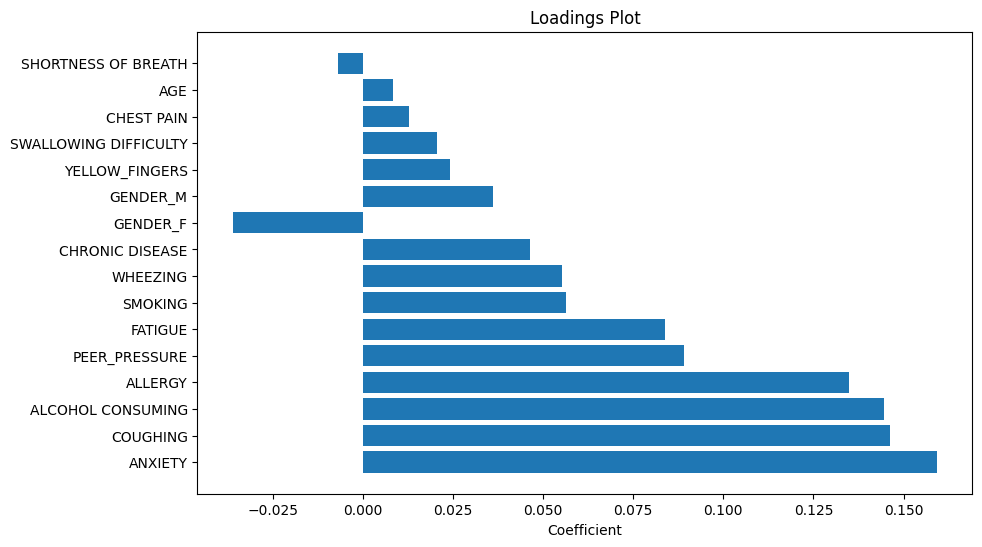

In [81]:
plt.figure(figsize=(10, 6))
plt.barh(coef_df['Feature'], coef_df['Coefficient'])
plt.xlabel('Coefficient')
plt.title('Loadings Plot')
plt.show()

#Knn Regression

In [82]:
#Hyperparameter tuning using GridSearchCV for KNNRegression
param_grid = {'n_neighbors': range(1, 21)}
grid_search_knn = GridSearchCV(KNeighborsRegressor(), param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search_knn.fit(train, y_train)

# For retrieving the optimal k
best_k = grid_search_knn.best_params_['n_neighbors']


In [83]:
#Trained model with the optimal k
model_knn_reg = KNeighborsRegressor(n_neighbors=best_k)
model_knn_reg.fit(train, y_train)

KNeighborsRegressor(n_neighbors=14)

In [84]:
#Predict and evaluate
y_pred_knn_reg = model_knn_reg.predict(val)
mse_knn_reg = mean_squared_error(y_val, y_pred_knn_reg)
rmse_knn_reg = np.sqrt(mse_knn_reg)
mae_knn_reg = mean_absolute_error(y_val, y_pred_knn_reg)

print(f"KNN Regression RMSE: {rmse_knn_reg}")
print(f"KNN Regression MAE: {mae_knn_reg}")

KNN Regression RMSE: 0.33370069728032026
KNN Regression MAE: 0.171889400921659


#KNN classification


In [85]:
#Hyperparameter tuning using GridSearchCV for KNN Classification
param_grid = {'n_neighbors': range(1, 21)}
grid_search_knn_cls = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')
grid_search_knn_cls.fit(train, y_train)

# Retrieve the optimal k value
best_k_cls = grid_search_knn_cls.best_params_['n_neighbors']

# Train KNN Classification model with the optimal k
model_knn_cls = KNeighborsClassifier(n_neighbors=best_k_cls)
model_knn_cls.fit(train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [86]:
# Prediction and evaluate
y_pred_knn_cls = model_knn_cls.predict(val)
accuracy_knn_cls = accuracy_score(y_val, y_pred_knn_cls)
precision_knn_cls = precision_score(y_val, y_pred_knn_cls)
recall_knn_cls = recall_score(y_val, y_pred_knn_cls)
f1_knn_cls = f1_score(y_val, y_pred_knn_cls)

In [87]:
# Calculate specificity
tn, fp, fn, tp = confusion_matrix(y_val, y_pred_knn_cls).ravel()
specificity_knn_cls = tn / (tn + fp)

In [88]:
print(f"KNN Classification Accuracy: {accuracy_knn_cls}")
print(f"KNN Classification Precision: {precision_knn_cls}")
print(f"KNN Classification Recall: {recall_knn_cls}")
print(f"KNN Classification F1-Score: {f1_knn_cls}")
print(f"KNN Classification Specificity: {specificity_knn_cls}")

KNN Classification Accuracy: 0.8516129032258064
KNN Classification Precision: 0.8639455782312925
KNN Classification Recall: 0.9769230769230769
KNN Classification F1-Score: 0.9169675090252708
KNN Classification Specificity: 0.2
